Testing the idea of using Virtual distillation on two modes with an ancilla qubit

In [127]:
#Run B matrix circuit on various input states
using QuantumOptics
using Plots
using LinearAlgebra
println(Threads.nthreads())
println(Sys.CPU_THREADS)
println(BLAS.get_num_threads())
BLAS.set_num_threads(1)
println(BLAS.get_num_threads())

b_spin = SpinBasis(1//2)
b_motion = FockBasis(50)
b_coll_2m = b_spin ⊗ b_motion 


const sx = sigmax(b_spin)
const sy = sigmay(b_spin)
const sz = sigmaz(b_spin)
const sp = (sx + 1im*sy)/2
const sm = (sx - 1im*sy)/2

const up = spinup(b_spin)
const down = spindown(b_spin)
const I_s = identityoperator(b_spin)

const ad = create(b_motion)
const a = destroy(b_motion)
const I_m = identityoperator(b_motion)
const n = QuantumOptics.number(b_motion)


function squeeze_one(r=0.5, θ=0)
    """ squeeze one mode """
    ξ = r*exp(1im*θ*2)
    # Squeeze the first mode
    S = exp(1/2 * (conj(ξ)*a^2 - ξ*ad^2))
    return S
end

function trisqueeze_one(r=0.5, θ=0)
    """ trisqueeze one mode """
    ξ = r*exp(1im*θ*2)
    # Squeeze the first mode
    T = exp(1/2 * (conj(ξ)*a^3 - ξ*ad^3))
    return T
end

const P_down = dm(down)
const P_up = dm(up)

const Hadamard = (sx + sz) / sqrt(2)
const H_ancilla = tensor(Hadamard, I_m )
const S_ancilla = tensor(exp(1im*pi/4*sz), I_m )

function D(beta)
    """ displacement propagator """
    return exp(beta * ad - conj(beta) * a)
end


function sdf(beta)
    """ spin dependent force """
    return P_up ⊗ D(beta)  +
            P_down ⊗ D(-beta)
end

const spin_up_state = dm(up) ⊗ I_m
const spin_down_state = dm(down) ⊗ I_m
function measure_spin(a)
    return real(expect(spin_up_state, a)) - real(expect(spin_down_state, a))
end

function get_chi_psi(psi, beta; do_re=true)
    " get single characteristic function value for state psi and point beta "
    if do_re
        U = H_ancilla * sdf(beta) * H_ancilla
    else
        U = H_ancilla *S_ancilla* sdf(beta) * H_ancilla
    end
    psi_out = U * psi
    return measure_spin(psi_out)
end

function get_linear_range(beta_min, beta_max, num_points)
    linear_range = LinRange(beta_min, beta_max, num_points)
    return linear_range
end

linear_range = get_linear_range(-1.5, 1.5, 5)


function get_characteristic_function_psi(psi, beta_max, num_points; do_re=true)
    beta_real_range = linear_range
    beta_imag_range = linear_range

    chi_arr = zeros(ComplexF64, num_points, num_points)

    Threads.@threads for idx in 1:(num_points * num_points)
        i = div(idx - 1, num_points) + 1
        j = mod(idx - 1, num_points) + 1

        beta = beta_real_range[i] + 1im * beta_imag_range[j]
        chi_arr[i, j] = get_chi_psi(psi, beta; do_re=do_re)
    end

    return chi_arr
end


dark_red    = RGB(0.62, 0.16, 0.17)
pastel_red  = RGB(0.81, 0.43, 0.43)
white       = RGB(1.00, 1.00, 1.00)
pastel_blue = RGB(0.62, 0.77, 0.90)
dark_blue   = RGB(0.16, 0.37, 0.56)

cmap = cgrad(
    [dark_blue, pastel_blue, white, pastel_red, dark_red],
    [0.0, 0.2, 0.45, 0.55, 0.8, 1.0]
)


function plot_char_fn(chi_arr, title_str, axis_labels, axis_ticks)
    max_val = maximum(abs.(chi_arr))
    max_val = 1.0 # overwrite to 1.0
    p = heatmap(linear_range, linear_range, real.(chi_arr), c=cmap, aspect_ratio=:equal, xlabel=axis_labels[1], ylabel=axis_labels[2], title=title_str, xticks=axis_ticks[1], yticks=axis_ticks[2], clims=(-max_val, max_val))
    return p
end

function check_w_norm(w)
    # Check that the Wigner function is properly normalized by integrating over the entire phase space
    dx = (linear_range[2] - linear_range[1])
    dy = (linear_range[2] - linear_range[1])
    integral = sum(w) * dx * dy
    println("Integral of Wigner function over phase space: ", integral)
end

function plot_wigner(state, lim=3)
    w = wigner(state, linear_range, linear_range); 
    check_w_norm(w)   

    max_val = maximum(abs.(w))
    axis_scale = linear_range
    lim = maximum(abs.(axis_scale))
    w_plt = heatmap(axis_scale, axis_scale, w, c=cmap,aspect_ratio=:equal,  xlabel="Re(γ)", ylabel="Im(γ)",  clims=(-max_val, max_val), xlims=(-lim, lim), ylims=(-lim, lim))
    plot(w_plt)
    hline!([0], color=:black, linestyle=:dash)
    vline!([0], color=:black, linestyle=:dash)
    hline!([-0.5, 0.5], color=:grey, linestyle=:dash)
    vline!([-0.5, 0.5], color=:grey, linestyle=:dash, legend=false)
    return w
end


1
16
1
1


plot_wigner (generic function with 2 methods)

First look at pure states to debug the derangement and characteristic function circuit

In [128]:
beta_min = -3.0
beta_max = 3.0
num_points = 41
linear_range = get_linear_range(beta_min, beta_max, num_points)

phi_2 = -3*pi/2
#phi_2 = pi/2
S = 0.15
fock_init = 0
psi_m = fockstate(b_motion, fock_init)
psi_m = trisqueeze_one(S, 0)*psi_m

psi_hybrid = tensor(up, psi_m)
beta_1 = 0.0 + 0.0im
psi_hybrid = sdf(beta_1)*psi_hybrid
rho_m1 = ptrace(psi_hybrid, [1])
w = plot_wigner(rho_m1)

Integral of Wigner function over phase space: 0.995889311347285


41×41 Matrix{Float64}:
 -1.56285e-6    1.21236e-5    1.16814e-6   …   1.21236e-5   -1.56285e-6
 -2.46303e-5   -3.54637e-6    2.09921e-6      -3.54637e-6   -2.46303e-5
 -7.51239e-6   -1.69822e-5   -1.10845e-5      -1.69822e-5   -7.51239e-6
  3.52272e-5    1.03942e-6   -1.22341e-5       1.03942e-6    3.52272e-5
  3.61733e-5    2.68091e-5    1.29186e-5       2.68091e-5    3.61733e-5
 -2.14765e-5    1.26964e-5    3.12966e-5   …   1.26964e-5   -2.14765e-5
 -5.98517e-5   -2.82851e-5    8.809e-6        -2.82851e-5   -5.98517e-5
 -1.75073e-5   -2.93633e-5   -2.67056e-5      -2.93633e-5   -1.75073e-5
  4.76013e-5    1.89238e-5   -2.46208e-5       1.89238e-5    4.76013e-5
  4.46914e-5    4.09617e-5    2.01337e-6       4.09617e-5    4.46914e-5
 -8.78393e-6   -1.51766e-6    2.92007e-6   …  -1.51766e-6   -8.78393e-6
 -3.15114e-5   -4.45345e-5   -1.15123e-5      -4.45345e-5   -3.15114e-5
 -1.56076e-5   -2.9273e-5     9.6276e-6       -2.9273e-5    -1.56076e-5
  ⋮                                      

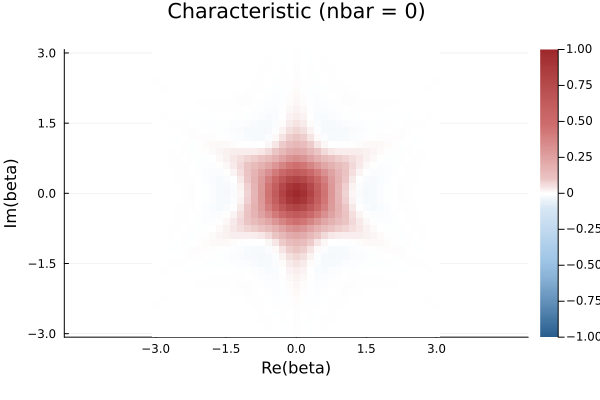

In [129]:
"""Plot real part """
axis_ticks = (LinRange(beta_min, beta_max, 5), LinRange(beta_min, beta_max, 5))

axis_labels = ("Re(beta)", "Im(beta)")
chi_arr_re = get_characteristic_function_psi(psi_hybrid, beta_max, num_points; do_re=true)
plot_title = "Characteristic (nbar = 0)"
p1 = plot_char_fn(chi_arr_re, plot_title, axis_labels, axis_ticks)

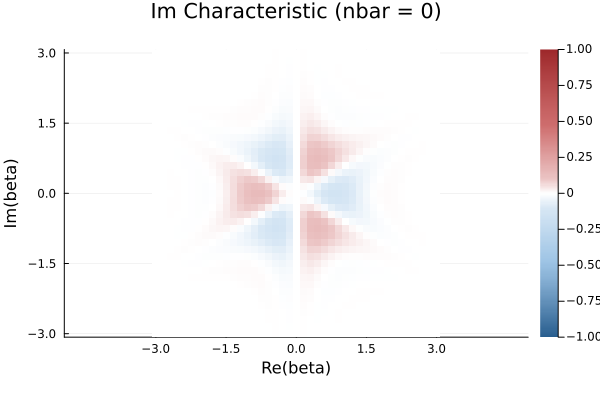

In [130]:
"""Plot imaginary part """
axis_ticks = (LinRange(beta_min, beta_max, 5), LinRange(beta_min, beta_max, 5))

axis_labels = ("Re(beta)", "Im(beta)")
chi_arr_im = get_characteristic_function_psi(psi_hybrid, beta_max, num_points, do_re=false)
plot_title = "Im Characteristic (nbar = 0)"
p2 = plot_char_fn(chi_arr_im, plot_title, axis_labels, axis_ticks)

In [131]:
using NPZ

npzwrite("heatmaps.npz", Dict(
    "A" => chi_arr_re,
    "B" => chi_arr_im,
    "C" => w,
    "x" => linear_range,
    "y" => linear_range
))